In [9]:
## -----------------------------------------------------------------------------
## Import packages
## -----------------------------------------------------------------------------
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    precision_score, roc_auc_score, average_precision_score,
    brier_score_loss, precision_recall_curve, roc_curve
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility (match R's behavior)
np.random.seed(42)

In [10]:
## -----------------------------------------------------------------------------
## Load and prepare data
## -----------------------------------------------------------------------------
df = pd.read_csv("../Data_ready_for_workshop2.csv")
df = pd.DataFrame(df)

# Split data
df_test = df[df['split'] == 'test']
df_cal = df[df['split'] == 'calibration']
df_train = df[df['split'] == 'train']
df_val = df[df['split'] == 'validation']

# Define features and target
X = df.drop(columns=['event_1y', 'id', 'split', 'date'])
y = df['event_1y']
X_train = df_train.drop(columns=['event_1y', 'id', 'split', 'date'])
y_train = df_train['event_1y']
X_val = df_val.drop(columns=['event_1y', 'id', 'split', 'date'])
y_val = df_val['event_1y']
X_test = df_test.drop(columns=['event_1y', 'id', 'split', 'date'])
y_test = df_test['event_1y']
X_cal = df_cal.drop(columns=['event_1y', 'id', 'split', 'date'])
y_cal = df_cal['event_1y']


In [11]:
# Preprocessing
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

In [12]:
## -----------------------------------------------------------------------------
## Logistic Regression
## -----------------------------------------------------------------------------
blr_mod = LogisticRegression(
    penalty=None,
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

blr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', blr_mod)
])

blr_pipeline.fit(X_train, y_train)
blr_val_pred_proba = blr_pipeline.predict_proba(X_val)[:, 1]


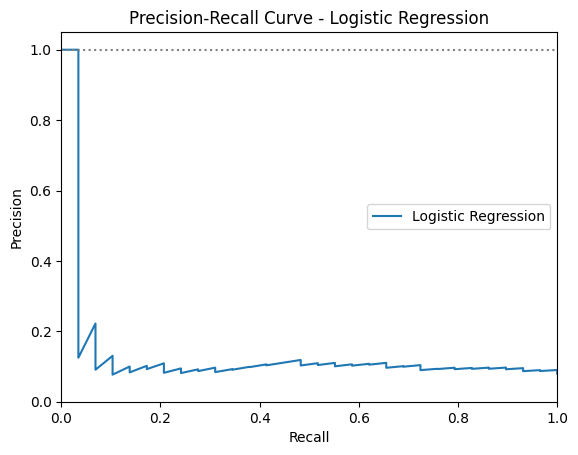

In [13]:
# PR curve for Logistic Regression
precision, recall, _ = precision_recall_curve(y_val, blr_val_pred_proba)
plt.figure()
plt.plot(recall, precision, label='Logistic Regression')
plt.title("Precision-Recall Curve - Logistic Regression")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.axhline(y=1, color='gray', linestyle=':')
plt.legend()
plt.show()


In [14]:
## -----------------------------------------------------------------------------
## Elastic Net (with manual grid search)
## -----------------------------------------------------------------------------
penalty_values = 10 ** np.linspace(-6, -2, 101)
mixture_values = np.linspace(0, 1, 11)
param_grid = [{'C': [1/p for p in penalty_values], 'l1_ratio': mixture_values}]

best_pr_auc = 0
best_params = None
best_model = None

for params in ParameterGrid(param_grid):
    el_mod = LogisticRegression(
        penalty='elasticnet',
        C=params['C'],
        l1_ratio=params['l1_ratio'],
        solver='saga',
        max_iter=1000,
        random_state=42
    )
    el_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', el_mod)
    ])
    el_pipeline.fit(X_train, y_train)
    val_pred_proba = el_pipeline.predict_proba(X_val)[:, 1]
    pr_auc = average_precision_score(y_val, val_pred_proba)

    if pr_auc > best_pr_auc:
        best_pr_auc = pr_auc
        best_params = params
        best_model = el_pipeline

print(f"Best parameters: C={best_params['C']}, l1_ratio={best_params['l1_ratio']}")
print(f"Best PR AUC: {best_pr_auc}")

# Retrain best model on full training + validation data
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])
preprocessor.fit(X_train_full)  # Re-fit preprocessor on full data

el_final = LogisticRegression(
    penalty='elasticnet',
    C=best_params['C'],
    l1_ratio=best_params['l1_ratio'],
    solver='saga',
    max_iter=1000,
    random_state=42
)
el_final.fit(preprocessor.transform(X_train_full), y_train_full)

Best parameters: C=1000000.0, l1_ratio=0.0
Best PR AUC: 0.13695976306813618


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'elasticnet'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",np.float64(1000000.0)
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",np.float64(0.0)
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class 

In [15]:
# Logistic Regression predictions on test set                                                                                                       
blr_pred_proba = blr_pipeline.predict_proba(X_test)[:, 1]                                                                                           
blr_pred = blr_pipeline.predict(X_test)                                                                                                             
                                                                                                                                                    
blr_metrics = {                                                                                                                                     
    'precision': precision_score(y_test, blr_pred),                                                                                                 
    'roc_auc': roc_auc_score(y_test, blr_pred_proba),                                                                                               
    'pr_auc': average_precision_score(y_test, blr_pred_proba),                                                                                      
    'brier': brier_score_loss(y_test, blr_pred_proba)                                                                                               
}                                                                                                                                                   
                                                                                                                                                   

In [17]:
# Elastic Net predictions on test set                                                                                                               
el_pred_proba = el_final.predict_proba(preprocessor.transform(X_test))[:, 1]                                                                        
el_pred = el_final.predict(preprocessor.transform(X_test))                                                                                          
                                                                                                                                                    
el_metrics = {
    'precision': precision_score(y_test, el_pred),                                                                                                  
    'roc_auc': roc_auc_score(y_test, el_pred_proba),                                                                                                
    'pr_auc': average_precision_score(y_test, el_pred_proba),                                                                                       
    'brier': brier_score_loss(y_test, el_pred_proba)                                                                                                
}         

In [18]:
# Print metrics
print("\nLogistic Regression Metrics:")
for metric, value in blr_metrics.items():
    print(f"  {metric}: {value:.4f}")

print("\nElastic Net Metrics:")
for metric, value in el_metrics.items():
    print(f"  {metric}: {value:.4f}")

# Performance comparison table
results = pd.DataFrame({
    'model': ['Logistic'] * 4 + ['Elastic Net'] * 4,
    '.metric': ['precision', 'roc_auc', 'pr_auc', 'brier'] * 2,
    '.estimate': list(blr_metrics.values()) + list(el_metrics.values())
})
print("\nPerformance Comparison:")
print(results.pivot(index='.metric', columns='model', values='.estimate'))



Logistic Regression Metrics:
  precision: 0.0000
  roc_auc: 0.5701
  pr_auc: 0.1448
  brier: 0.0968

Elastic Net Metrics:
  precision: 0.0000
  roc_auc: 0.5783
  pr_auc: 0.1459
  brier: 0.0959

Performance Comparison:
model      Elastic Net  Logistic
.metric                         
brier         0.095921  0.096772
pr_auc        0.145922  0.144846
precision     0.000000  0.000000
roc_auc       0.578345  0.570098


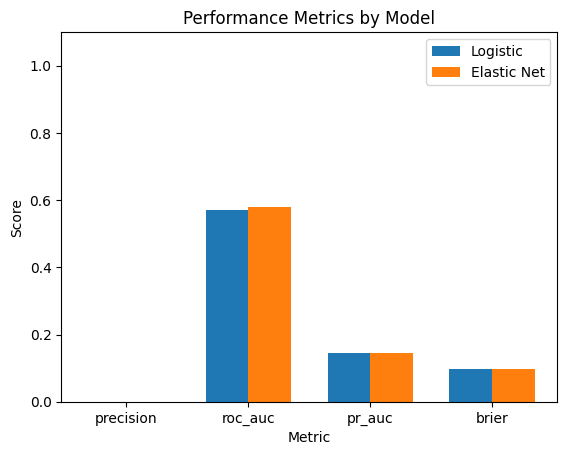

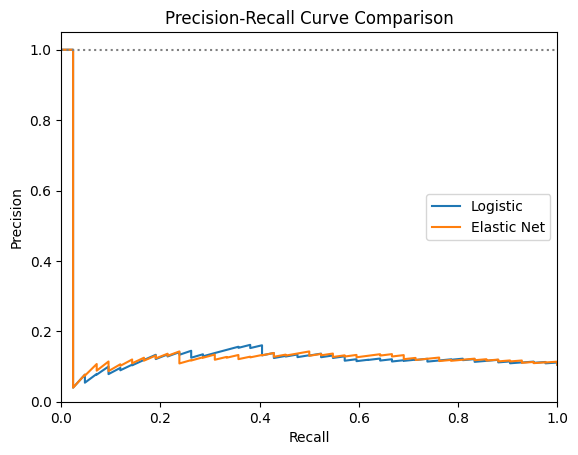

In [19]:
# Performance metrics barplot
plt.figure()
metrics_order = ['precision', 'roc_auc', 'pr_auc', 'brier']
x = np.arange(len(metrics_order))
width = 0.35
for i, model in enumerate(['Logistic', 'Elastic Net']):
    model_data = results[results['model'] == model]
    values = [model_data[model_data['.metric'] == m]['.estimate'].values[0] for m in metrics_order]
    plt.bar(x + i * width, values, width, label=model)
plt.title("Performance Metrics by Model")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim([0, 1.1])
plt.xticks(x + width / 2, metrics_order)
plt.legend()
plt.show()

# PR curve for both models
precision_blr, recall_blr, _ = precision_recall_curve(y_test, blr_pred_proba)
precision_el, recall_el, _ = precision_recall_curve(y_test, el_pred_proba)

plt.figure()
plt.plot(recall_blr, precision_blr, label='Logistic')
plt.plot(recall_el, precision_el, label='Elastic Net')
plt.title("Precision-Recall Curve Comparison")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.axhline(y=1, color='gray', linestyle=':')
plt.legend()
plt.show()



Top 20 features - Logistic Regression:
           feature  coefficient importance_type
10            chol    -0.259063     coefficient
25             age     0.210041     coefficient
3       hemoglobin     0.194765     coefficient
17           fruit    -0.167231     coefficient
9              crp     0.160617     coefficient
30    smoker_never    -0.159463     coefficient
2     erythrocytes    -0.142088     coefficient
24             ace     0.118583     coefficient
23         statins    -0.117484     coefficient
29   smoker_former     0.111428     coefficient
32  hyperlipidemia     0.110115     coefficient
14         anxiety     0.104862     coefficient
0         systolic     0.104527     coefficient
15           sleep     0.098254     coefficient
4              wbc     0.090573     coefficient
31        diabetes     0.087692     coefficient
12             ldl     0.077225     coefficient
33    hypertension    -0.063780     coefficient
16         alcohol    -0.056109     coefficient


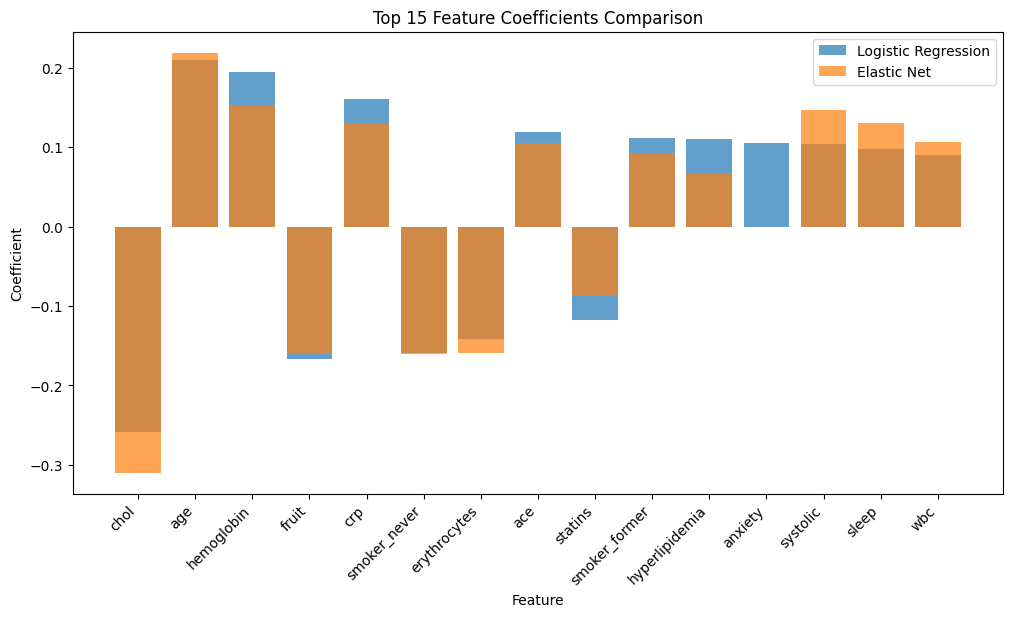

In [23]:
## -----------------------------------------------------------------------------
## Feature Importance
## -----------------------------------------------------------------------------
# Get feature names after one-hot encoding
cat_encoder = preprocessor.named_transformers_['cat']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_cols) if categorical_cols else []
all_feature_names = numeric_cols + list(cat_feature_names)

# Logistic Regression
blr_coef = pd.DataFrame({                                                                                                                           
    'feature': all_feature_names,                                                                                                                   
    'coefficient': blr_pipeline.named_steps['classifier'].coef_[0],
    'importance_type': 'coefficient'                                                                                                                
}).sort_values('coefficient', key=abs, ascending=False).head(20)

print("\nTop 20 features - Logistic Regression:")
print(blr_coef)

# Elastic Net
el_coef = pd.DataFrame({
    'feature': all_feature_names,
    'coefficient': el_final.coef_[0],
    'importance_type': 'coefficient'
}).sort_values('coefficient', key=abs, ascending=False).head(20)

print("\nTop 20 features - Elastic Net:")
print(el_coef)

# Feature importance bar chart
blr_coef['model'] = 'Logistic Regression'
el_coef['model'] = 'Elastic Net'

all_features = pd.concat([blr_coef[['feature', 'coefficient', 'model']], 
                          el_coef[['feature', 'coefficient', 'model']]])

top_n = 15
all_top_features = list(blr_coef['feature'].head(top_n)) + list(el_coef['feature'].head(top_n))
unique_features = list(dict.fromkeys(all_top_features))[:top_n]

plt.figure(figsize=(12, 6))
for model in ['Logistic Regression', 'Elastic Net']:
    model_data = all_features[all_features['model'] == model]
    model_coefs = []
    for feat in unique_features:
        coef = model_data[model_data['feature'] == feat]['coefficient'].values
        model_coefs.append(coef[0] if len(coef) > 0 else 0)
    plt.bar(unique_features, model_coefs, label=model, alpha=0.7)
plt.title(f'Top {top_n} Feature Coefficients Comparison')
plt.xlabel("Feature")
plt.ylabel("Coefficient")
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.show()


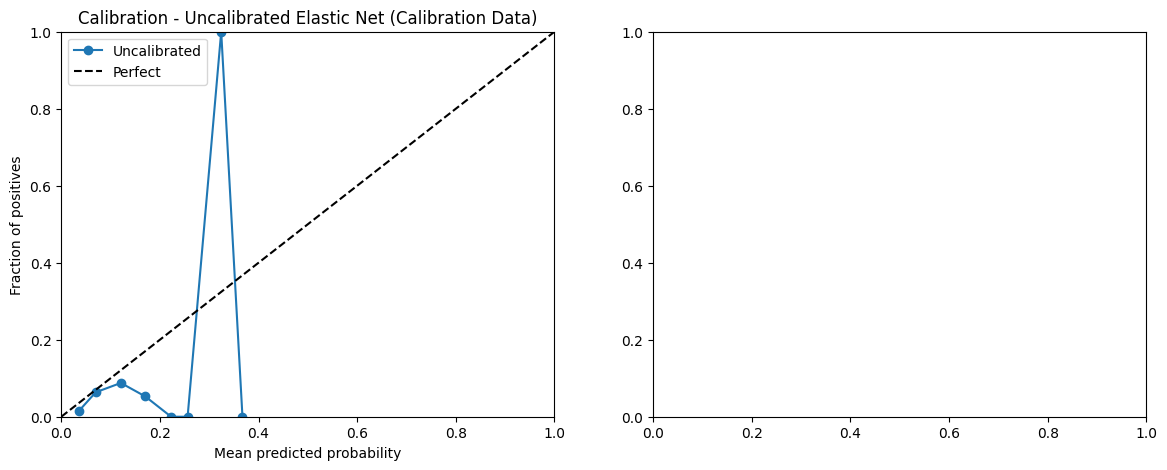

In [24]:
## -----------------------------------------------------------------------------
## Calibration
## -----------------------------------------------------------------------------
# Predictions on test and calibration data
el_test_pred = pd.DataFrame({
    '.row': X_test.index,
    'el': el_pred_proba,
    'event_1y': y_test.values
})

el_cal_pred_proba = el_final.predict_proba(preprocessor.transform(X_cal))[:, 1]
el_cal_pred = pd.DataFrame({
    'el': el_cal_pred_proba,
    'event_1y': y_cal.values
})

calibrated_el = CalibratedClassifierCV(
    Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(
            penalty='elasticnet',
            C=best_params['C'],
            l1_ratio=best_params['l1_ratio'],
            solver='saga',
            max_iter=1000,
            random_state=42
        ))
    ]),
    method='sigmoid',
    cv=2
)
calibrated_el.fit(X_cal, y_cal)

el_cal_pred['el_calibrated'] = calibrated_el.predict_proba(X_cal)[:, 1]
el_test_pred['el_calibrated'] = calibrated_el.predict_proba(X_test)[:, 1]

# Calibration plots for calibration data (side by side)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Uncalibrated - calibration data
prob_true_uncal, prob_pred_uncal = calibration_curve(el_cal_pred['event_1y'], el_cal_pred['el'], n_bins=20)
ax1.plot(prob_pred_uncal, prob_true_uncal, 'o-', label='Uncalibrated')
ax1.plot([0, 1], [0, 1], 'k--', label='Perfect')
ax1.set_xlabel('Mean predicted probability')
ax1.set_ylabel('Fraction of positives')
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1])
ax1.set_title("Calibration - Uncalibrated Elastic Net (Calibration Data)")
ax1.legend()


<Figure size 640x480 with 0 Axes>

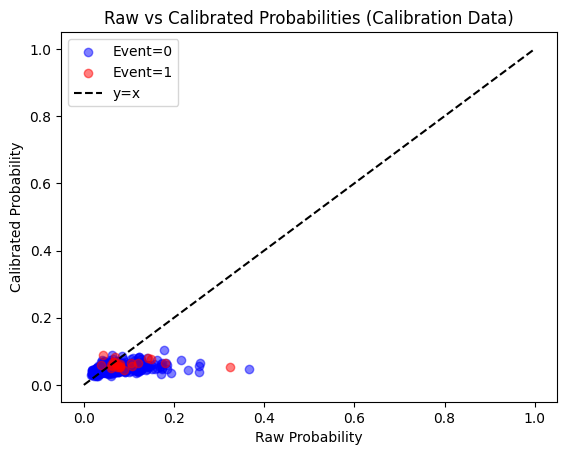

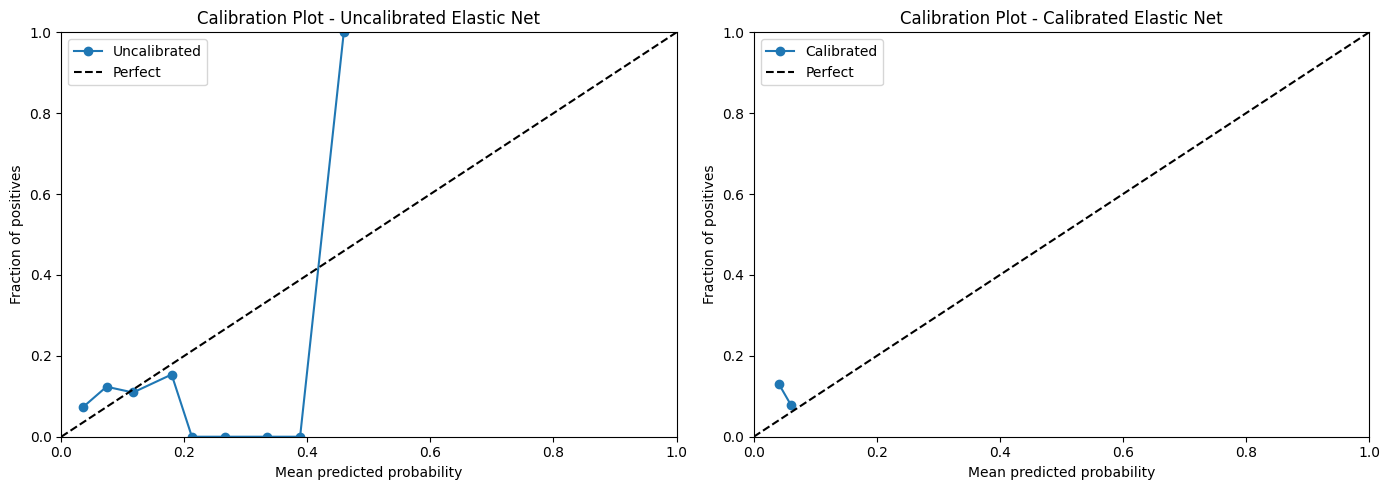

In [25]:
# Calibrated - calibration data
prob_true_cal, prob_pred_cal = calibration_curve(el_cal_pred['event_1y'], el_cal_pred['el_calibrated'], n_bins=20)
ax2.plot(prob_pred_cal, prob_true_cal, 'o-', label='Calibrated')
ax2.plot([0, 1], [0, 1], 'k--', label='Perfect')
ax2.set_xlabel('Mean predicted probability')
ax2.set_ylabel('Fraction of positives')
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1])
ax2.set_title("Calibration - Calibrated Elastic Net (Calibration Data)")
ax2.legend()

plt.tight_layout()
plt.show()

# Scatter plot: raw vs calibrated
plt.figure()
colors = {'0': 'blue', '1': 'red'}
for event in [0, 1]:
    mask = el_cal_pred['event_1y'] == event
    plt.scatter(el_cal_pred.loc[mask, 'el'], el_cal_pred.loc[mask, 'el_calibrated'], 
                color=colors[str(event)], label=f'Event={event}', alpha=0.5)
plt.plot([0, 1], [0, 1], 'k--', label='y=x')
plt.title("Raw vs Calibrated Probabilities (Calibration Data)")
plt.xlabel('Raw Probability')
plt.ylabel('Calibrated Probability')
plt.legend()
plt.show()

# Final calibration plots for test data (side by side)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Uncalibrated - test data
prob_true_t_uncal, prob_pred_t_uncal = calibration_curve(el_test_pred['event_1y'], el_test_pred['el'], n_bins=20)
ax1.plot(prob_pred_t_uncal, prob_true_t_uncal, 'o-', label='Uncalibrated')
ax1.plot([0, 1], [0, 1], 'k--', label='Perfect')
ax1.set_xlabel('Mean predicted probability')
ax1.set_ylabel('Fraction of positives')
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1])
ax1.set_title("Calibration Plot - Uncalibrated Elastic Net")
ax1.legend()

# Calibrated - test data
prob_true_t_cal, prob_pred_t_cal = calibration_curve(el_test_pred['event_1y'], el_test_pred['el_calibrated'], n_bins=20)
ax2.plot(prob_pred_t_cal, prob_true_t_cal, 'o-', label='Calibrated')
ax2.plot([0, 1], [0, 1], 'k--', label='Perfect')
ax2.set_xlabel('Mean predicted probability')
ax2.set_ylabel('Fraction of positives')
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1])
ax2.set_title("Calibration Plot - Calibrated Elastic Net")
ax2.legend()

plt.tight_layout()
plt.show()
